In [1]:
!pip install git+https://github.com/neurallatents/nlb_tools.git
!pip install dandi
!dandi download https://gui.dandiarchive.org/dandiset/000127
!pip install git+https://github.com/neurallatents/nlb_tools.git --no-deps
!pip install pynwb elephant pyyaml

  Cloning https://github.com/neurallatents/nlb_tools.git to /tmp/pip-req-build-wmdbxmy1
  Running command git clone --filter=blob:none --quiet https://github.com/neurallatents/nlb_tools.git /tmp/pip-req-build-wmdbxmy1
  Resolved https://github.com/neurallatents/nlb_tools.git to commit 42f8410b88e12db136910fa2f888b025ea0aa2ae
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 71.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See abov

## Comparison Metrics: RSA, DSA, CCA.

Compares RNN hidden-state dynamics with real neural data using
established neuroscience comparison metrics:

  1. RSA  — Representational Similarity Analysis
             Compare condition-level RDMs between real PSTHs and RNN hidden states.
  2. DSA  — Dynamical Similarity Analysis
             Compare linear dynamics (fitted A matrices) between real and model
             trajectories using Procrustes distance on eigenspectra.
  3. CCA  — Canonical Correlation Analysis
             Find maximally correlated linear projections between real and model
             latent spaces (condition-averaged trajectories).
  4. Procrustes — Orthogonal Procrustes alignment of neural trajectories.
  5. Behavioral — Compare decoded hand velocity R² from real vs model.

In [2]:
from __future__ import annotations

import os
import json
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional, List, Dict, Tuple, Union

import numpy as np
import h5py
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.linalg import orthogonal_procrustes
from scipy.stats import spearmanr, pearsonr


# CORE COMPONENTS: CONFIG, LOADERS, METRICS, PLOTS

# CONFIG
@dataclass
class ComparisonConfig:
    """All knobs for metric computation."""
    rnn_ready_h5: Union[str, Path] = "/kaggle/input/notebooks/abdelwhabmohamed05/rnn-data-prep/area2_bump_rnn_ready.h5"
    hidden_h5: Union[str, Path] = "/kaggle/input/notebooks/abdelwhabmohamed05/rnn-training/rnn_hidden_states.h5"
    out_dir: Union[str, Path] = "/kaggle/working"

    # RSA
    rsa_distance: str = "correlation"
    rsa_time_window_ms: Tuple[int, int] = (0, 500)

    # DSA
    dsa_n_delays: int = 1
    dsa_regularization: float = 1e-3

    # CCA
    cca_n_components: int = 10

    # PCA for trajectory comparison
    pca_n_components: int = 3

    # Plot settings
    max_conditions_to_plot: int = 16

    def resolved_paths(self) -> Dict[str, Path]:
        out = Path(self.out_dir)
        fig = out / "figures"
        out.mkdir(parents=True, exist_ok=True)
        fig.mkdir(parents=True, exist_ok=True)
        return {
            "rnn_ready_h5": Path(self.rnn_ready_h5),
            "hidden_h5": Path(self.hidden_h5),
            "out_dir": out,
            "fig_dir": fig,
            "metrics_json": out / "comparison_metrics.json",
        }


# DATA LOADERS
def load_real_psth(h5_path: Path) -> Tuple[np.ndarray, List[str]]:
    """Load condition-averaged PSTHs from the RNN-ready H5.

    returns:
        psth:         (n_conditions, n_time, n_neurons)
        label_order:  list of condition labels
    """
    with h5py.File(h5_path, "r") as f:
        psth = f["canonical_psth"][:]
        labels = [s.decode() if isinstance(s, bytes) else s
                  for s in f["condition_labels"][:]]
    return psth, labels


def load_real_split_psth(h5_path: Path, split: str = "train") -> Optional[np.ndarray]:
    """Load per-split PSTH if available."""
    with h5py.File(h5_path, "r") as f:
        key = f"splits/{split}/psth"
        if key in f:
            return f[key][:]
    return None


def load_model_hidden_states(h5_path: Path) -> Dict[str, Dict[str, np.ndarray]]:
    """Load all model hidden states from the H5.

    returns dict: model_name → {cond_avg, all_hidden, cond_ids}
    """
    models = {}
    with h5py.File(h5_path, "r") as f:
        for name in f.keys():
            if name == "condition_labels":
                continue
            grp = f[name]
            models[name] = {
                "cond_avg": grp["cond_avg"][:],
                "all_hidden": grp["all_hidden"][:],
                "cond_ids": grp["cond_ids"][:],
            }
    return models


# REPRESENTATIONAL SIMILARITY ANALYSIS
def compute_rdm(
    psth: np.ndarray,
    time_bins_ms: Optional[np.ndarray] = None,
    time_window: Optional[Tuple[int, int]] = None,
    distance: str = "correlation",
) -> np.ndarray:
    """Compute representational dissimilarity matrix.

    Args:
        psth: (n_conditions, n_time, n_features)
        time_bins_ms: (n_time,) — used to select time window
        time_window: (start_ms, end_ms) — if provided, average within window
        distance: distance metric for pdist

    returns:
        rdm: (n_conditions, n_conditions) symmetric dissimilarity matrix
    """
    # Time-window average or full concatenation
    if time_window is not None and time_bins_ms is not None:
        t0, t1 = time_window
        tmask = (time_bins_ms >= t0) & (time_bins_ms <= t1)
        if tmask.any():
            vectors = psth[:, tmask, :].mean(axis=1)  # (C, F)
        else:
            vectors = psth.mean(axis=1)
    else:
        # Concatenate time × features into a single vector per condition
        vectors = psth.reshape(psth.shape[0], -1)

    # Handle NaN conditions
    valid = ~np.isnan(vectors).any(axis=1)
    n = vectors.shape[0]
    rdm = np.full((n, n), np.nan)

    if valid.sum() < 2:
        return rdm

    valid_vectors = vectors[valid]
    if distance == "correlation":
        dists = pdist(valid_vectors, metric="correlation")
    elif distance == "cosine":
        dists = pdist(valid_vectors, metric="cosine")
    else:
        dists = pdist(valid_vectors, metric=distance)

    valid_rdm = squareform(dists)
    valid_idx = np.where(valid)[0]
    for i, vi in enumerate(valid_idx):
        for j, vj in enumerate(valid_idx):
            rdm[vi, vj] = valid_rdm[i, j]

    return rdm


def compare_rdms(rdm1: np.ndarray, rdm2: np.ndarray) -> Dict[str, float]:
    """Compare two RDMs using Spearman and Pearson correlation.

    returns dict with rsa_spearman, rsa_pearson, rsa_kendall.
    """
    # Extract upper triangle (excluding diagonal)
    n = rdm1.shape[0]
    triu_idx = np.triu_indices(n, k=1)
    v1 = rdm1[triu_idx]
    v2 = rdm2[triu_idx]

    # Remove NaN pairs
    valid = ~(np.isnan(v1) | np.isnan(v2))
    if valid.sum() < 3:
        return {"rsa_spearman": float("nan"), "rsa_pearson": float("nan")}

    v1, v2 = v1[valid], v2[valid]
    rho_s, p_s = spearmanr(v1, v2)
    rho_p, p_p = pearsonr(v1, v2)

    return {
        "rsa_spearman": float(rho_s),
        "rsa_spearman_p": float(p_s),
        "rsa_pearson": float(rho_p),
        "rsa_pearson_p": float(p_p),
    }


# DYNAMICAL SIMILARITY ANALYSIS
def fit_linear_dynamics(
    trajectories: np.ndarray,
    n_delays: int = 1,
    regularization: float = 1e-3,
) -> np.ndarray:
    """Fit a linear dynamical system x(t+1) = A x(t) to trajectories.

    args:
        trajectories: (n_conditions, n_time, n_features)
        n_delays: number of time-delay embeddings
        regularization: ridge regularization

    returns:
        a: (d, d) dynamics matrix where d = n_features * n_delays
    """
    C, T, D = trajectories.shape
    d = D * n_delays

    # Build delay-embedded state vectors
    X_list, Y_list = [], []
    for c in range(C):
        traj = trajectories[c]
        if np.isnan(traj).any():
            continue
        for t in range(n_delays, T - 1):
            state = np.concatenate([traj[t - k] for k in range(n_delays)])
            next_state = np.concatenate([traj[t + 1 - k] for k in range(n_delays)])
            X_list.append(state)
            Y_list.append(next_state)

    if len(X_list) < d:
        return np.eye(d) * np.nan

    X = np.array(X_list)
    Y = np.array(Y_list)

    # Ridge regression: A = Y^T X (X^T X + λI)^{-1}
    XtX = X.T @ X + regularization * np.eye(d)
    XtY = X.T @ Y
    A = np.linalg.solve(XtX, XtY).T

    return A


def compute_dsa_distance(A1: np.ndarray, A2: np.ndarray) -> Dict[str, float]:
    """Compare two dynamics matrices using eigenvalue analysis.

    DSA compares the eigenspectra and eigenvector alignment.
    """
    if np.isnan(A1).any() or np.isnan(A2).any():
        return {"dsa_eigenvalue_distance": float("nan"),
                "dsa_procrustes_distance": float("nan")}

    # Eigendecomposition
    eig1 = np.linalg.eigvals(A1)
    eig2 = np.linalg.eigvals(A2)

    # Sort by magnitude (descending)
    idx1 = np.argsort(-np.abs(eig1))
    idx2 = np.argsort(-np.abs(eig2))
    eig1 = eig1[idx1]
    eig2 = eig2[idx2]

    n = min(len(eig1), len(eig2))
    eig1, eig2 = eig1[:n], eig2[:n]

    eig_dist = float(np.sqrt(np.sum((np.abs(eig1) - np.abs(eig2)) ** 2)))
    complex_dist = float(np.sqrt(np.sum(np.abs(eig1 - eig2) ** 2)))

    # Spectral radius comparison
    sr1 = float(np.max(np.abs(eig1)))
    sr2 = float(np.max(np.abs(eig2)))

    return {
        "dsa_eigenvalue_distance": eig_dist,
        "dsa_complex_distance": complex_dist,
        "dsa_spectral_radius_1": sr1,
        "dsa_spectral_radius_2": sr2,
        "dsa_spectral_radius_diff": abs(sr1 - sr2),
    }


# CANONICAL CORRELATION ANALYSIS
def compute_cca(
    X: np.ndarray,
    Y: np.ndarray,
    n_components: int = 10,
) -> Dict[str, np.ndarray]:
    """Compute CCA between two sets of condition-averaged trajectories.

    rrgs:
        X: (n_conditions, n_time, n_features_x) — real neural data
        Y: (n_conditions, n_time, n_features_y) — model hidden states

    returns:
        dict with canonical correlations and projections.
    """
    # Flatten: (C*T, F)
    C, T = X.shape[0], X.shape[1]
    Xf = X.reshape(C * T, -1)
    Yf = Y.reshape(C * T, -1)

    # Remove NaN rows
    valid = ~(np.isnan(Xf).any(axis=1) | np.isnan(Yf).any(axis=1))
    Xf, Yf = Xf[valid], Yf[valid]

    if Xf.shape[0] < n_components:
        return {"canonical_correlations": np.array([]),
                "mean_canonical_corr": float("nan")}
    Xf = Xf - Xf.mean(axis=0)
    Yf = Yf - Yf.mean(axis=0)

    # SVD-based CCA
    n = min(n_components, Xf.shape[1], Yf.shape[1], Xf.shape[0] - 1)
    if n < 1:
        return {"canonical_correlations": np.array([]),
                "mean_canonical_corr": float("nan")}

    # QR decomposition for numerical stability
    Qx, Rx = np.linalg.qr(Xf, mode="reduced")
    Qy, Ry = np.linalg.qr(Yf, mode="reduced")

    # SVD of Q_x^T Q_y
    U, s, Vt = np.linalg.svd(Qx.T @ Qy, full_matrices=False)
    canon_corrs = np.clip(s[:n], 0, 1)

    return {
        "canonical_correlations": canon_corrs.astype(np.float64),
        "mean_canonical_corr": float(np.mean(canon_corrs)),
        "max_canonical_corr": float(np.max(canon_corrs)) if len(canon_corrs) > 0 else float("nan"),
    }


# PROCRUSTES ALIGNMENT
def compute_procrustes_distance(
    X: np.ndarray,
    Y: np.ndarray,
    n_pcs: int = 3,
) -> Dict[str, float]:
    """Orthogonal Procrustes alignment of PCA-projected trajectories.

    args:
        X: (n_conditions, n_time, n_features_x)
        Y: (n_conditions, n_time, n_features_y)
        n_pcs: number of PCA components for projection
    """
    from sklearn.decomposition import PCA

    # Flatten conditions × time
    C, T = X.shape[0], X.shape[1]
    Xf = X.reshape(C * T, -1)
    Yf = Y.reshape(C * T, -1)

    valid = ~(np.isnan(Xf).any(axis=1) | np.isnan(Yf).any(axis=1))
    Xf, Yf = Xf[valid], Yf[valid]

    if Xf.shape[0] < n_pcs:
        return {"procrustes_distance": float("nan")}

    # PCA
    n = min(n_pcs, Xf.shape[1], Yf.shape[1])
    Xp = PCA(n_components=n).fit_transform(Xf)
    Yp = PCA(n_components=n).fit_transform(Yf)
    Xp -= Xp.mean(axis=0)
    Yp -= Yp.mean(axis=0)

    # Scale to unit Frobenius norm
    Xp /= np.linalg.norm(Xp)
    Yp /= np.linalg.norm(Yp)

    # Orthogonal Procrustes
    R, scale = orthogonal_procrustes(Xp, Yp)
    Xp_aligned = Xp @ R

    # Distance after alignment
    dist = float(np.sqrt(np.sum((Xp_aligned - Yp) ** 2)))

    return {
        "procrustes_distance": dist,
        "procrustes_scale": float(scale),
    }


# PLOTTING
def plot_rdm_comparison(
    rdm_real: np.ndarray,
    rdm_models: Dict[str, np.ndarray],
    labels: List[str],
    out_path: Path,
) -> None:
    """Plot RDMs side by side: real + each model."""
    n = 1 + len(rdm_models)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4.5))
    if n == 1:
        axes = [axes]

    def _plot_rdm(ax, rdm, title):
        im = ax.imshow(rdm, cmap="RdBu_r", vmin=0, vmax=np.nanmax(rdm))
        ax.set_title(title, fontsize=10)
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=90, fontsize=5)
        ax.set_yticks(range(len(labels)))
        ax.set_yticklabels(labels, fontsize=5)
        plt.colorbar(im, ax=ax, fraction=0.046)

    _plot_rdm(axes[0], rdm_real, "Real Neural RDM")
    for i, (name, rdm) in enumerate(rdm_models.items()):
        _plot_rdm(axes[i + 1], rdm, f"Model: {name}")

    fig.tight_layout()
    fig.savefig(out_path, dpi=150)
    plt.close(fig)


def plot_rsa_summary(
    rsa_results: Dict[str, Dict[str, float]],
    out_path: Path,
) -> None:
    """Bar chart of RSA correlations across models."""
    names = list(rsa_results.keys())
    spearman = [rsa_results[n].get("rsa_spearman", 0) for n in names]
    pearson = [rsa_results[n].get("rsa_pearson", 0) for n in names]

    x = np.arange(len(names))
    fig, ax = plt.subplots(figsize=(max(8, len(names) * 1.5), 5))
    w = 0.35
    ax.bar(x - w / 2, spearman, w, label="Spearman ρ", color="steelblue")
    ax.bar(x + w / 2, pearson, w, label="Pearson r", color="coral")
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Correlation with real RDM")
    ax.set_title("RSA: Model vs Real Neural Representations")
    ax.legend()
    ax.axhline(0, color="k", linewidth=0.5)
    fig.tight_layout()
    fig.savefig(out_path, dpi=120)
    plt.close(fig)


def plot_cca_spectrum(
    cca_results: Dict[str, Dict],
    out_path: Path,
) -> None:
    """Plot canonical correlation spectra for each model."""
    fig, ax = plt.subplots(figsize=(10, 5))
    cmap = plt.cm.tab10
    for i, (name, res) in enumerate(cca_results.items()):
        cc = res.get("canonical_correlations", np.array([]))
        if isinstance(cc, list):
            cc = np.array(cc)
        if len(cc) > 0:
            ax.plot(range(1, len(cc) + 1), cc, "o-",
                    color=cmap(i % 10), label=name, alpha=0.8)
    ax.set_xlabel("CCA component")
    ax.set_ylabel("Canonical correlation")
    ax.set_title("CCA: Real Neural vs Model Hidden States")
    ax.legend(fontsize=7)
    ax.set_ylim(0, 1.05)
    fig.tight_layout()
    fig.savefig(out_path, dpi=120)
    plt.close(fig)


def plot_metrics_summary(
    all_metrics: Dict[str, Dict],
    out_path: Path,
) -> None:
    """Summary dashboard: RSA, DSA, CCA, Procrustes for each model."""
    names = list(all_metrics.keys())
    metric_keys = ["rsa_spearman", "mean_canonical_corr",
                   "procrustes_distance", "dsa_eigenvalue_distance"]
    metric_labels = ["RSA (Spearman ρ)", "CCA (mean corr)",
                     "Procrustes dist", "DSA (eigval dist)"]

    fig, axes = plt.subplots(1, len(metric_keys), figsize=(4 * len(metric_keys), 5))
    for i, (key, label) in enumerate(zip(metric_keys, metric_labels)):
        ax = axes[i]
        vals = [all_metrics[n].get(key, float("nan")) for n in names]
        colors = ["steelblue" if not np.isnan(v) else "lightgray" for v in vals]
        ax.barh(range(len(names)), vals, color=colors)
        ax.set_yticks(range(len(names)))
        ax.set_yticklabels(names, fontsize=7)
        ax.set_xlabel(label)
        ax.set_title(label, fontsize=9)
    fig.suptitle("Model Comparison Summary", fontsize=12, y=1.02)
    fig.tight_layout()
    fig.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.close(fig)

# COMPARISON DRIVER

if __name__ == "__main__":
    cfg = ComparisonConfig()
    paths = cfg.resolved_paths()
    summary: Dict = {"config": {k: str(v) if isinstance(v, Path) else v
                                for k, v in cfg.__dict__.items()}}

    # Check inputs exist
    for key in ["rnn_ready_h5", "hidden_h5"]:
        if not paths[key].exists():
            raise FileNotFoundError(
                f"{key} not found at {paths[key]}. "
                f"Run the preceding scripts first."
            )

    # Load real neural PSTHs
    real_psth, label_order = load_real_psth(paths["rnn_ready_h5"])
    n_conditions, n_time, n_neurons = real_psth.shape
    summary["real_data"] = {
        "n_conditions": n_conditions,
        "n_time": n_time,
        "n_neurons": n_neurons,
        "labels": label_order,
    }

    # Build time bins for windowing
    with h5py.File(paths["rnn_ready_h5"], "r") as f:
        align_range = f.attrs.get("align_range_ms", (-100, 500))
        bin_width = f.attrs.get("bin_width_ms", 5)
    time_bins_ms = np.linspace(align_range[0], align_range[1],
                                n_time, endpoint=False).astype(int)

    # Load model hidden states
    model_data = load_model_hidden_states(paths["hidden_h5"])
    summary["models_loaded"] = list(model_data.keys())

    # Compute real RDM
    real_rdm = compute_rdm(real_psth, time_bins_ms, cfg.rsa_time_window_ms,
                            cfg.rsa_distance)

    # Per-model comparisons
    all_metrics = {}
    model_rdms = {}
    rsa_results = {}
    cca_results = {}

    for model_name, mdata in model_data.items():
        cond_avg = mdata["cond_avg"]
        metrics = {}

        # RSA
        model_rdm = compute_rdm(cond_avg, time_bins_ms, cfg.rsa_time_window_ms,
                                 cfg.rsa_distance)
        model_rdms[model_name] = model_rdm
        rsa = compare_rdms(real_rdm, model_rdm)
        metrics.update(rsa)
        rsa_results[model_name] = rsa

        # DSA
        # Fit linear dynamics to real and model trajectories
        A_real = fit_linear_dynamics(real_psth, cfg.dsa_n_delays,
                                     cfg.dsa_regularization)
        A_model = fit_linear_dynamics(cond_avg, cfg.dsa_n_delays,
                                      cfg.dsa_regularization)
        dsa = compute_dsa_distance(A_real, A_model)
        metrics.update(dsa)

        # CCA
        cca = compute_cca(real_psth, cond_avg, cfg.cca_n_components)
        # Convert numpy arrays to lists for JSON serialization
        cca_serializable = {}
        for k, v in cca.items():
            if isinstance(v, np.ndarray):
                cca_serializable[k] = v.tolist()
            else:
                cca_serializable[k] = v
        metrics.update(cca_serializable)
        cca_results[model_name] = cca

        # Procrustes
        proc = compute_procrustes_distance(
            real_psth, cond_avg, cfg.pca_n_components
        )
        metrics.update(proc)

        all_metrics[model_name] = metrics

    summary["metrics"] = all_metrics

    # Plots
    if model_rdms:
        plot_rdm_comparison(
            real_rdm, model_rdms, label_order,
            paths["fig_dir"] / "cmp_01_rdm_comparison.png",
        )
        plot_rsa_summary(
            rsa_results,
            paths["fig_dir"] / "cmp_02_rsa_summary.png",
        )
    if cca_results:
        plot_cca_spectrum(
            cca_results,
            paths["fig_dir"] / "cmp_03_cca_spectrum.png",
        )
    if all_metrics:
        plot_metrics_summary(
            all_metrics,
            paths["fig_dir"] / "cmp_04_metrics_summary.png",
        )

    # write JSON summary
    with open(paths["metrics_json"], "w") as f:
        json.dump(summary, f, indent=2, default=str)

    # Summary statistics
    n_models = len(all_metrics)
    if all_metrics:
        best_rsa = max(all_metrics.items(),
                       key=lambda x: x[1].get("rsa_spearman", -1))
        best_cca = max(all_metrics.items(),
                       key=lambda x: x[1].get("mean_canonical_corr", -1))
    else:
        best_rsa = ("none", {"rsa_spearman": float("nan")})
        best_cca = ("none", {"mean_canonical_corr": float("nan")})

    print(f"[comparison] OK  models={n_models} "
          f"best_RSA={best_rsa[0]}({best_rsa[1].get('rsa_spearman', 0):.3f}) "
          f"best_CCA={best_cca[0]}({best_cca[1].get('mean_canonical_corr', 0):.3f}) "
          f"-> {paths['metrics_json']}")


[comparison] OK  models=3 best_RSA=decoder_GRU_h128(0.797) best_CCA=autoencoder_GRU_h128(1.000) -> /kaggle/working/comparison_metrics.json


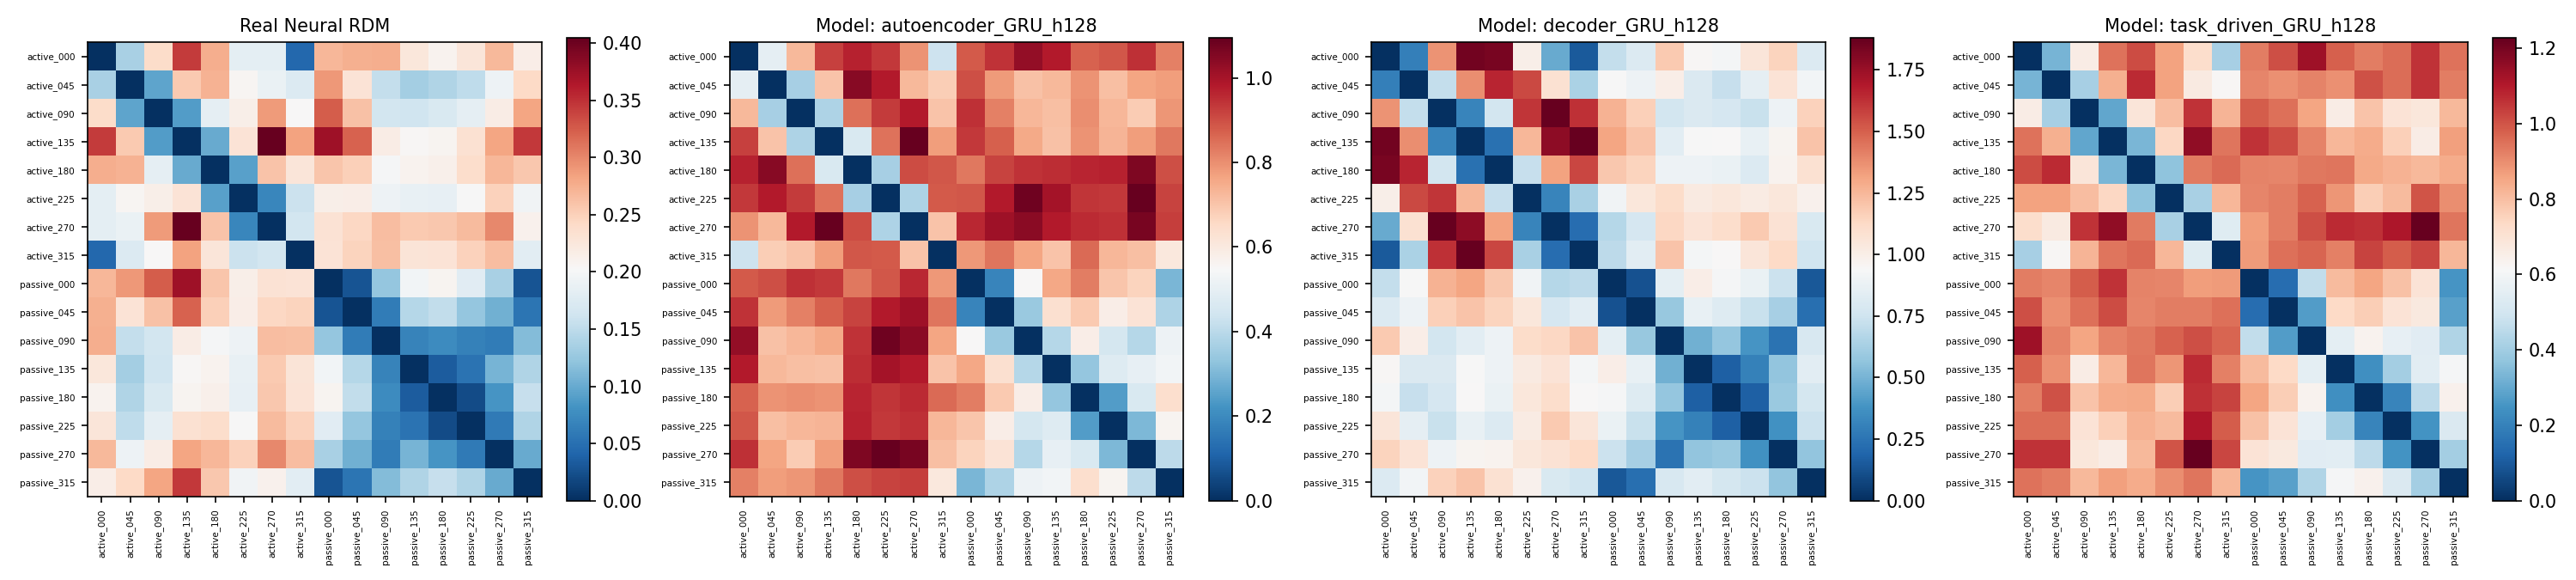

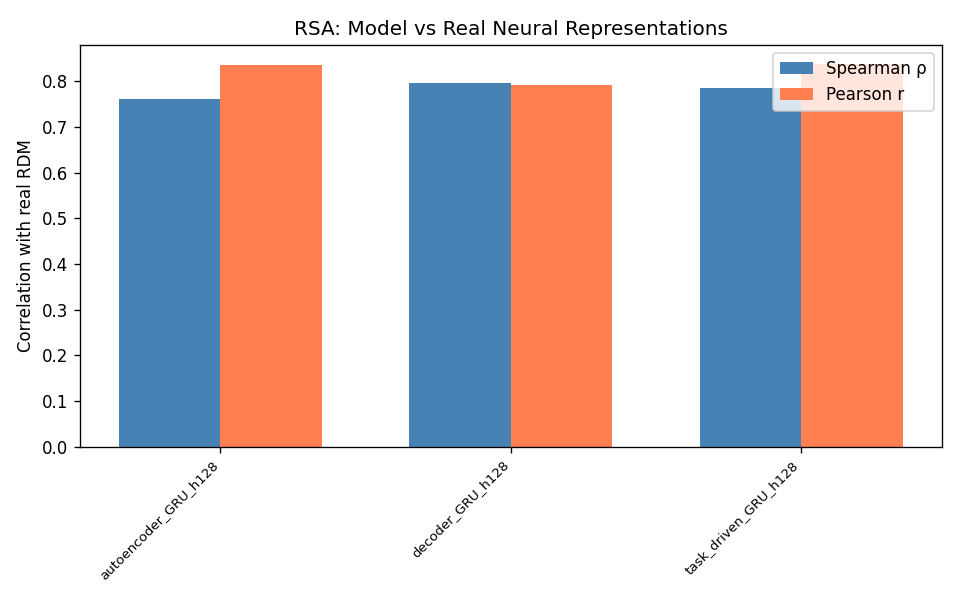

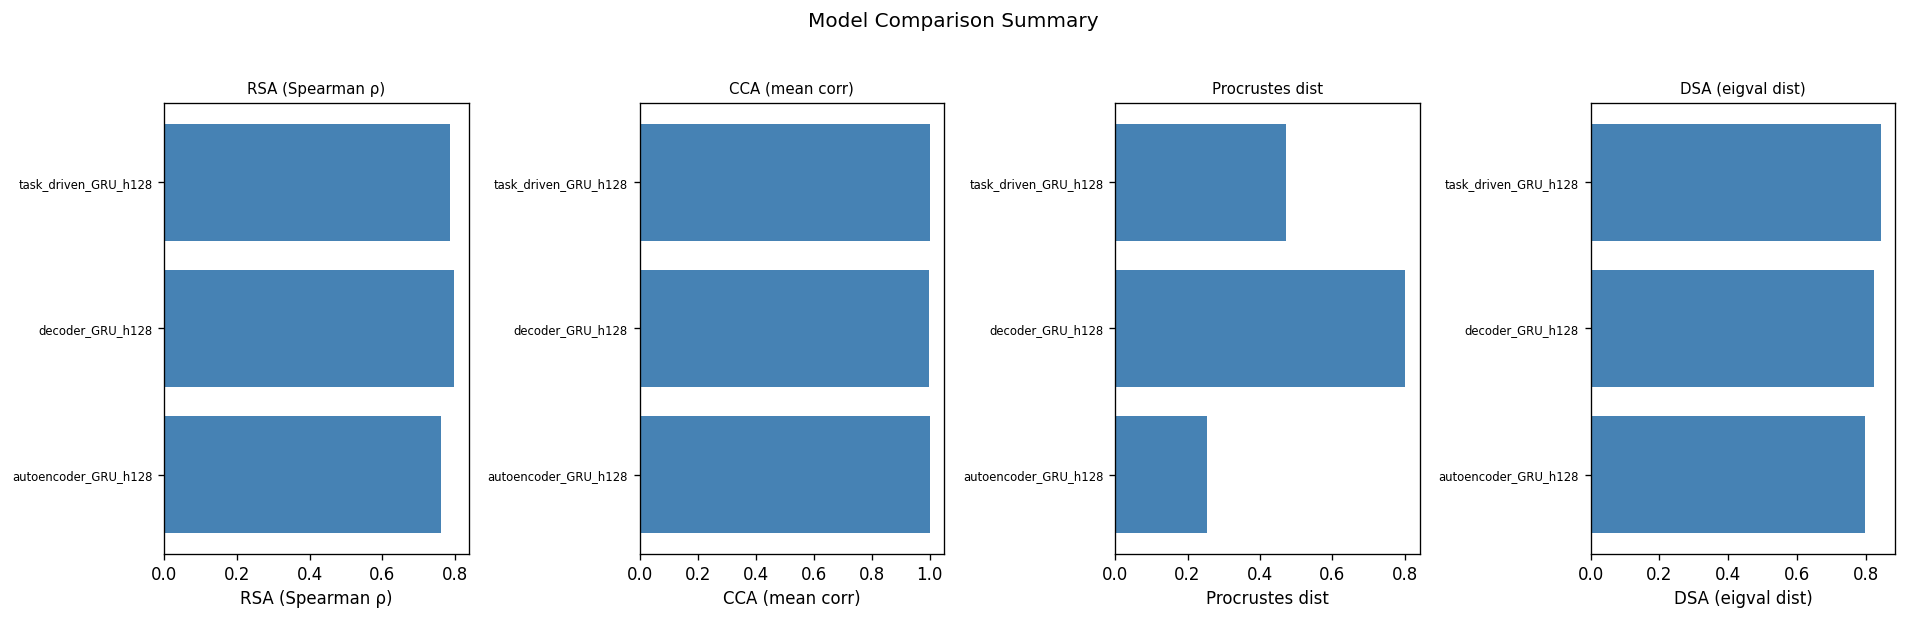

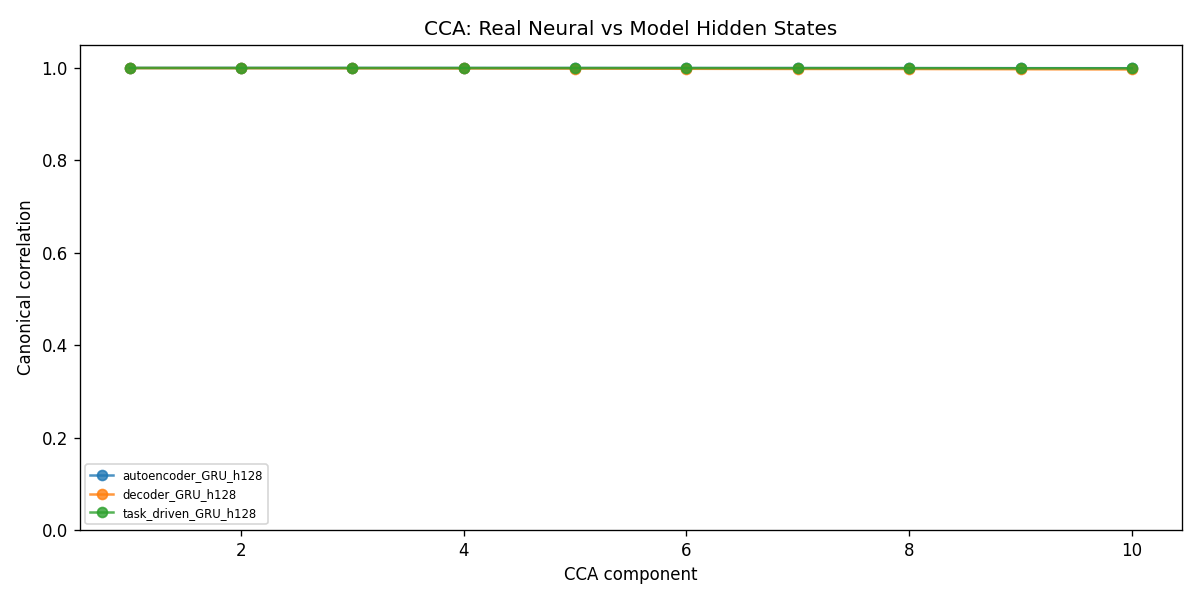

In [3]:
from IPython.display import Image, display
import glob

for img_path in glob.glob("/kaggle/working/figures/*.png"):
    display(Image(filename=img_path))